Generating random obstacle environment...
Generated environment after 1 attempt(s).
Number of obstacle cells: 36

Creating initial population...
Starting Genetic Algorithm...

Generation   0 | Fitness:  -908.00 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  10 | Fitness:  -909.50 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  20 | Fitness:  -909.50 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  30 | Fitness:  -909.50 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  40 | Fitness:  -911.00 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  50 | Fitness:  -911.00 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  60 | Fitness:  -911.00 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  70 | Fitness:  -911.00 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  80 | Fitness:  -918.50 | Position: (23, 23) | Collisions: 0 | Repeated: 0
Generation  90 | Fitness:  -918.50 | Position: (23

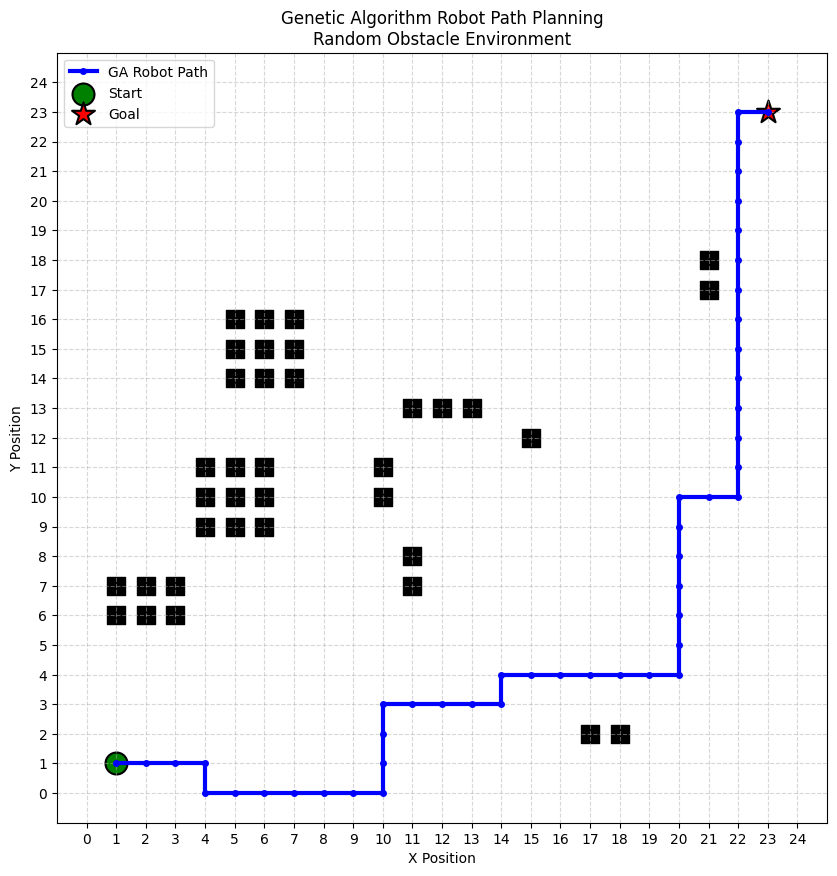

In [1]:
import random
import math
import matplotlib.pyplot as plt


# ============================================================
# 1. ENVIRONMENT SETTINGS
# ============================================================

GRID_SIZE = 25

START = (1, 1)
GOAL = (23, 23)

# Number of randomly generated obstacles
NUMBER_OF_OBSTACLES = 35

# Small obstacle sizes
MIN_OBSTACLE_SIZE = 1
MAX_OBSTACLE_SIZE = 3


# ============================================================
# 2. GENETIC ALGORITHM SETTINGS
# ============================================================

POPULATION_SIZE = 150
GENERATIONS = 500

MUTATION_RATE = 0.08
TOURNAMENT_SIZE = 5

# Maximum number of movements in a chromosome
PATH_LENGTH = 70


# ============================================================
# 3. POSSIBLE ROBOT MOVEMENTS
# ============================================================

MOVES = [
    (0, 1),      # Up
    (1, 0),      # Right
    (0, -1),     # Down
    (-1, 0)      # Left
]


# ============================================================
# 4. GENERATE RANDOM OBSTACLES
# ============================================================

def generate_obstacles():

    obstacles = set()

    attempts = 0

    max_attempts = NUMBER_OF_OBSTACLES * 100

    while (
        len(obstacles) < NUMBER_OF_OBSTACLES
        and attempts < max_attempts
    ):

        attempts += 1

        # Random top-left corner
        x = random.randint(
            1,
            GRID_SIZE - MAX_OBSTACLE_SIZE - 1
        )

        y = random.randint(
            1,
            GRID_SIZE - MAX_OBSTACLE_SIZE - 1
        )

        # Random obstacle size
        width = random.randint(
            MIN_OBSTACLE_SIZE,
            MAX_OBSTACLE_SIZE
        )

        height = random.randint(
            MIN_OBSTACLE_SIZE,
            MAX_OBSTACLE_SIZE
        )

        new_cells = set()

        for dx in range(width):

            for dy in range(height):

                cell = (
                    x + dx,
                    y + dy
                )

                # Make sure cell is inside grid
                if (
                    0 <= cell[0] < GRID_SIZE
                    and
                    0 <= cell[1] < GRID_SIZE
                ):

                    new_cells.add(cell)

        # ----------------------------------------------------
        # Don't place obstacles on start or goal
        # ----------------------------------------------------

        if START in new_cells:
            continue

        if GOAL in new_cells:
            continue

        # ----------------------------------------------------
        # Keep obstacles separated somewhat
        #
        # This prevents the entire map becoming one giant wall.
        # ----------------------------------------------------

        too_close = False

        for obstacle_cell in new_cells:

            for existing_cell in obstacles:

                distance = abs(
                    obstacle_cell[0]
                    - existing_cell[0]
                ) + abs(
                    obstacle_cell[1]
                    - existing_cell[1]
                )

                if distance <= 1:

                    too_close = True
                    break

            if too_close:
                break

        if too_close:
            continue

        # Add obstacle
        obstacles.update(new_cells)

    return obstacles


# ============================================================
# 5. CHECK WHETHER GOAL IS REACHABLE
# ============================================================

def is_reachable(obstacles):

    queue = [START]

    visited = {START}

    while queue:

        current = queue.pop(0)

        if current == GOAL:
            return True

        x, y = current

        for dx, dy in MOVES:

            new_position = (
                x + dx,
                y + dy
            )

            # Check boundaries
            if not (
                0 <= new_position[0] < GRID_SIZE
                and
                0 <= new_position[1] < GRID_SIZE
            ):
                continue

            # Check obstacle
            if new_position in obstacles:
                continue

            # Check visited
            if new_position in visited:
                continue

            visited.add(new_position)

            queue.append(new_position)

    return False


# ============================================================
# 6. GENERATE A VALID ENVIRONMENT
# ============================================================

print("Generating random obstacle environment...")

attempt = 0

while True:

    attempt += 1

    OBSTACLES = generate_obstacles()

    if is_reachable(OBSTACLES):
        break

    if attempt > 100:

        print(
            "Could not generate a valid environment."
        )

        exit()


print(
    f"Generated environment after {attempt} attempt(s)."
)

print(
    f"Number of obstacle cells: {len(OBSTACLES)}"
)


# ============================================================
# 7. CREATE INITIAL INDIVIDUAL
# ============================================================

def create_individual():

    path = []

    current = START

    previous_move = None

    for _ in range(PATH_LENGTH):

        # ----------------------------------------------------
        # Direction toward goal
        # ----------------------------------------------------

        dx = GOAL[0] - current[0]
        dy = GOAL[1] - current[1]

        preferred_moves = []

        if dx > 0:
            preferred_moves.append((1, 0))

        elif dx < 0:
            preferred_moves.append((-1, 0))

        if dy > 0:
            preferred_moves.append((0, 1))

        elif dy < 0:
            preferred_moves.append((0, -1))

        # ----------------------------------------------------
        # Possible moves
        # ----------------------------------------------------

        possible_moves = MOVES.copy()

        # Don't immediately reverse direction
        if previous_move is not None:

            reverse = (
                -previous_move[0],
                -previous_move[1]
            )

            if reverse in possible_moves:

                possible_moves.remove(
                    reverse
                )

        # ----------------------------------------------------
        # Prefer movement toward goal
        # ----------------------------------------------------

        if (
            preferred_moves
            and
            random.random() < 0.75
        ):

            move = random.choice(
                preferred_moves
            )

        else:

            move = random.choice(
                possible_moves
            )

        path.append(move)

        # ----------------------------------------------------
        # Calculate new position
        # ----------------------------------------------------

        new_position = (
            current[0] + move[0],
            current[1] + move[1]
        )

        # ----------------------------------------------------
        # Only update position if valid
        # ----------------------------------------------------

        if (
            0 <= new_position[0] < GRID_SIZE
            and
            0 <= new_position[1] < GRID_SIZE
            and
            new_position not in OBSTACLES
        ):

            current = new_position

        previous_move = move

    return path


# ============================================================
# 8. SIMULATE ROBOT PATH
# ============================================================

def simulate_path(individual):

    x, y = START

    path = [(x, y)]

    visited = {START}

    collisions = 0
    repeated_cells = 0

    for dx, dy in individual:

        new_x = x + dx
        new_y = y + dy

        # ----------------------------------------------------
        # Boundary check
        # ----------------------------------------------------

        if not (
            0 <= new_x < GRID_SIZE
            and
            0 <= new_y < GRID_SIZE
        ):

            collisions += 1

            continue

        # ----------------------------------------------------
        # Obstacle check
        # ----------------------------------------------------

        if (new_x, new_y) in OBSTACLES:

            collisions += 1

            continue

        # ----------------------------------------------------
        # Repeated cell
        # ----------------------------------------------------

        if (new_x, new_y) in visited:

            repeated_cells += 1

        # ----------------------------------------------------
        # Move robot
        # ----------------------------------------------------

        x = new_x
        y = new_y

        path.append(
            (x, y)
        )

        visited.add(
            (x, y)
        )

        # ----------------------------------------------------
        # Goal reached
        # ----------------------------------------------------

        if (x, y) == GOAL:

            break

    return (
        path,
        collisions,
        repeated_cells
    )


# ============================================================
# 9. FITNESS FUNCTION
# ============================================================

def fitness(individual):

    path, collisions, repeated = simulate_path(
        individual
    )

    final_position = path[-1]

    # --------------------------------------------------------
    # Distance to goal
    # --------------------------------------------------------

    distance_to_goal = math.sqrt(

        (final_position[0] - GOAL[0]) ** 2

        +

        (final_position[1] - GOAL[1]) ** 2
    )

    # --------------------------------------------------------
    # Path length
    # --------------------------------------------------------

    path_length = 0

    for i in range(1, len(path)):

        x1, y1 = path[i - 1]

        x2, y2 = path[i]

        path_length += math.sqrt(

            (x2 - x1) ** 2

            +

            (y2 - y1) ** 2
        )

    # --------------------------------------------------------
    # Number of turns
    # --------------------------------------------------------

    turns = 0

    for i in range(1, len(individual)):

        previous = individual[i - 1]

        current = individual[i]

        if previous != current:

            turns += 1

    # --------------------------------------------------------
    # Calculate fitness
    # Lower = better
    # --------------------------------------------------------

    score = (

        # Strongly encourage reaching goal
        distance_to_goal * 20

        # Prefer shorter paths
        + path_length

        # Discourage excessive turning
        + turns * 1.5

        # Strong collision penalty
        + collisions * 100

        # Strong repeated-cell penalty
        + repeated * 50
    )

    # --------------------------------------------------------
    # Huge reward for reaching goal
    # --------------------------------------------------------

    if final_position == GOAL:

        score -= 1000

    return score


# ============================================================
# 10. TOURNAMENT SELECTION
# ============================================================

def selection(population):

    tournament = random.sample(
        population,
        TOURNAMENT_SIZE
    )

    return min(
        tournament,
        key=fitness
    )


# ============================================================
# 11. CROSSOVER
# ============================================================

def crossover(parent1, parent2):

    point = random.randint(
        1,
        PATH_LENGTH - 1
    )

    child = (
        parent1[:point]
        +
        parent2[point:]
    )

    return child


# ============================================================
# 12. MUTATION
# ============================================================

def mutate(individual):

    for i in range(
        len(individual)
    ):

        if random.random() < MUTATION_RATE:

            current_move = individual[i]

            possible_moves = []

            for move in MOVES:

                # Don't choose same movement
                if move == current_move:
                    continue

                # Don't immediately reverse
                if i > 0:

                    previous_move = (
                        individual[i - 1]
                    )

                    reverse = (
                        -previous_move[0],
                        -previous_move[1]
                    )

                    if move == reverse:
                        continue

                possible_moves.append(
                    move
                )

            if possible_moves:

                individual[i] = random.choice(
                    possible_moves
                )

    return individual


# ============================================================
# 13. CREATE INITIAL POPULATION
# ============================================================

print("\nCreating initial population...")

population = [
    create_individual()
    for _ in range(
        POPULATION_SIZE
    )
]


# ============================================================
# 14. RUN GENETIC ALGORITHM
# ============================================================

print(
    "Starting Genetic Algorithm...\n"
)

best_individual = None

best_score = float("inf")

goal_reached_generation = None


for generation in range(
    GENERATIONS
):

    # --------------------------------------------------------
    # Find best individual
    # --------------------------------------------------------

    current_best = min(
        population,
        key=fitness
    )

    current_score = fitness(
        current_best
    )

    # --------------------------------------------------------
    # Update global best
    # --------------------------------------------------------

    if current_score < best_score:

        best_score = current_score

        best_individual = (
            current_best.copy()
        )

    # --------------------------------------------------------
    # Check whether goal reached
    # --------------------------------------------------------

    best_path, collisions, repeated = (
        simulate_path(
            best_individual
        )
    )

    if (
        best_path[-1] == GOAL
        and
        goal_reached_generation is None
    ):

        goal_reached_generation = (
            generation
        )

    # --------------------------------------------------------
    # Print progress
    # --------------------------------------------------------

    if generation % 10 == 0:

        print(
            f"Generation {generation:3d} | "
            f"Fitness: {best_score:8.2f} | "
            f"Position: {best_path[-1]} | "
            f"Collisions: {collisions} | "
            f"Repeated: {repeated}"
        )

    # --------------------------------------------------------
    # New generation
    # --------------------------------------------------------

    new_population = []

    # Keep best individual
    new_population.append(
        current_best.copy()
    )

    while (
        len(new_population)
        <
        POPULATION_SIZE
    ):

        # Selection
        parent1 = selection(
            population
        )

        parent2 = selection(
            population
        )

        # Crossover
        child = crossover(
            parent1,
            parent2
        )

        # Mutation
        child = mutate(
            child
        )

        new_population.append(
            child
        )

    population = new_population


# ============================================================
# 15. FINAL PATH
# ============================================================

best_path, collisions, repeated = (
    simulate_path(
        best_individual
    )
)


# ============================================================
# 16. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 60)
print("FINAL RESULT")
print("=" * 60)

print(
    f"Grid size           : "
    f"{GRID_SIZE} x {GRID_SIZE}"
)

print(
    f"Obstacle cells      : "
    f"{len(OBSTACLES)}"
)

print(
    f"Start position      : "
    f"{START}"
)

print(
    f"Goal position       : "
    f"{GOAL}"
)

print(
    f"Final position      : "
    f"{best_path[-1]}"
)

print(
    f"Path length         : "
    f"{len(best_path)}"
)

print(
    f"Collisions          : "
    f"{collisions}"
)

print(
    f"Repeated cells      : "
    f"{repeated}"
)

print(
    f"Final fitness       : "
    f"{fitness(best_individual):.2f}"
)

if goal_reached_generation is not None:

    print(
        f"Goal first reached  : "
        f"generation {goal_reached_generation}"
    )


if best_path[-1] == GOAL:

    print("\nSUCCESS!")
    print(
        "The robot successfully "
        "reached the goal."
    )

else:

    print("\nThe robot did not reach the goal.")

    print(
        "Try increasing GENERATIONS "
        "or PATH_LENGTH."
    )


# ============================================================
# 17. VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 10)
)


# ------------------------------------------------------------
# Draw obstacles
# ------------------------------------------------------------

for x, y in OBSTACLES:

    plt.scatter(
        x,
        y,
        color="black",
        marker="s",
        s=150
    )


# ------------------------------------------------------------
# Draw robot path
# ------------------------------------------------------------

x_values = [
    position[0]
    for position in best_path
]

y_values = [
    position[1]
    for position in best_path
]


plt.plot(
    x_values,
    y_values,
    color="blue",
    linewidth=3,
    marker="o",
    markersize=4,
    label="GA Robot Path"
)


# ------------------------------------------------------------
# Draw start
# ------------------------------------------------------------

plt.scatter(
    START[0],
    START[1],
    color="green",
    s=250,
    marker="o",
    edgecolors="black",
    linewidths=1.5,
    label="Start"
)


# ------------------------------------------------------------
# Draw goal
# ------------------------------------------------------------

plt.scatter(
    GOAL[0],
    GOAL[1],
    color="red",
    s=300,
    marker="*",
    edgecolors="black",
    linewidths=1.5,
    label="Goal"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

plt.xlim(-1, GRID_SIZE)

plt.ylim(-1, GRID_SIZE)

plt.xticks(
    range(GRID_SIZE)
)

plt.yticks(
    range(GRID_SIZE)
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.xlabel(
    "X Position"
)

plt.ylabel(
    "Y Position"
)

plt.title(
    "Genetic Algorithm Robot Path Planning\n"
    "Random Obstacle Environment"
)

plt.legend()

plt.gca().set_aspect(
    "equal",
    adjustable="box"
)

plt.show()
